In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
import warnings


In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# df = train.__deepcopy__()

In [3]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27181440 entries, 0 to 27181439
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
 19  datetime              object 
dtypes: float64(14), int64(4), object(2)
memory usage: 4.1+ GB


,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
count,2.718144e+07,2.718144e+07,27181440.0,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07
mean,1.738267e+12,2.024791e+13,1.0,2.149938e+02,2.149946e+02,2.149946e+02,3.723699e+02,3.723706e+02,3.723699e+02,1.749953e+01,1.749883e+01,1.750261e+01,3.009975e+03,9.246984e+01,9.247057e+01,9.246874e+01,6.019512e+02,7.055947e+06
std,3.016970e+09,3.929252e+09,0.0,2.901866e+00,2.902405e+00,2.902151e+00,3.572511e+00,3.572509e+00,3.572434e+00,7.217245e+00,7.217796e+00,7.216499e+00,7.171598e+02,4.405668e+00,4.405326e+00,4.405634e+00,2.290593e+02,2.787661e+06
min,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901800e+02,1.901800e+02,3.310000e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,9.010000e+01,1.129004e+06
25%,1.735654e+12,2.024123e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503800e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231600e+02,4.870391e+06
50%,1.738267e+12,2.025013e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009950e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739800e+02,7.055739e+06
75%,1.740881e+12,2.025030e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749200e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515940e+03,9.625000e+01,9.625000e+01,9.624000e+01,7.553900e+02,9.241356e+06
max,1.743491e+12,2.025033e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.334350e+07


In [4]:
# # time stamp 컬럼 삭제 및 localtime을 datetime 형식으로 변환
train = train.drop(columns=['timestamp'])
# train['localtime'] = pd.to_datetime(train['localtime'], format='%Y%m%d%H%M%S')

test = test.drop(columns=['timestamp'])
# test['localtime'] = pd.to_datetime(test['localtime'], format='%Y%m%d%H%M%S')

In [5]:
train['accumActiveEnergy_kwh'] = train['accumActiveEnergy'] / 1000
test['accumActiveEnergy_kwh'] = test['accumActiveEnergy'] / 1000

In [6]:
train['powerFactorR'] /= 100
train['powerFactorS'] /= 100
train['powerFactorT'] /= 100

test['powerFactorR'] /= 100
test['powerFactorS'] /= 100
test['powerFactorT'] /= 100

In [7]:
# def create_electrical_features(data):
#     """전력공학적 의미가 있는 파생 특성 생성"""
#     features = pd.DataFrame(index=data.index)
    
#     # 전압 불균형
#     features['voltage_imbalance'] = (
#         (data['voltageR'] + data['voltageS'] + data['voltageT']) / 3 -
#         np.sqrt((data['voltageR']**2 + data['voltageS']**2 + data['voltageT']**2) / 3)
#     )
    
    
#     # 역률 평균 및 편차
#     features['power_factor_avg'] = data[['powerFactorR', 'powerFactorS', 'powerFactorT']].mean(axis=1)
#     features['power_factor_std'] = data[['powerFactorR', 'powerFactorS', 'powerFactorT']].std(axis=1)
    
#     # 전압-전류 관계
#     features['voltage_current_ratio'] = (
#         (data['voltageR'] + data['voltageS'] + data['voltageT']) / 
#         (data['currentR'] + data['currentS'] + data['currentT'] + 1e-8)
#     )
    
#     # 무효전력 대비 유효전력 비율
#     features['active_reactive_ratio'] = data['activePower'] / (data['reactivePowerLagging'] + 1e-8)
    
#     return features

In [8]:
# === 1단계: 기본 통계 특성 ===
print("1단계: 기본 통계 특성 생성 중...")

# 전압 관련
train['voltage_mean'] = train[['voltageR', 'voltageS', 'voltageT']].mean(axis=1)
train['voltage_std'] = train[['voltageR', 'voltageS', 'voltageT']].std(axis=1)
train['voltageline_mean'] = train[['voltageRS', 'voltageST', 'voltageTR']].mean(axis=1)
train['voltageline_std'] = train[['voltageRS', 'voltageST', 'voltageTR']].std(axis=1)

test['voltage_mean'] = test[['voltageR', 'voltageS', 'voltageT']].mean(axis=1)
test['voltage_std'] = test[['voltageR', 'voltageS', 'voltageT']].std(axis=1)
test['voltageline_mean'] = test[['voltageRS', 'voltageST', 'voltageTR']].mean(axis=1)
test['voltageline_std'] = test[['voltageRS', 'voltageST', 'voltageTR']].std(axis=1)

# 전류 관련
train['current_mean'] = train[['currentR', 'currentS', 'currentT']].mean(axis=1)
train['current_std'] = train[['currentR', 'currentS', 'currentT']].std(axis=1)

test['current_mean'] = test[['currentR', 'currentS', 'currentT']].mean(axis=1)
test['current_std'] = test[['currentR', 'currentS', 'currentT']].std(axis=1)

print("1단계 완료!")

1단계: 기본 통계 특성 생성 중...
1단계 완료!


In [9]:
# === 2단계: 불균형 및 역률 특성 ===
print("2단계: 불균형 및 역률 특성 생성 중...")

# 전압 불균형
train['voltage_imbalance'] = (
    train['voltage_mean'] - 
    np.sqrt((train['voltageR']**2 + train['voltageS']**2 + train['voltageT']**2) / 3)
)

test['voltage_imbalance'] = (
    test['voltage_mean'] - 
    np.sqrt((test['voltageR']**2 + test['voltageS']**2 + test['voltageT']**2) / 3)
)

# 전류 불균형
train['current_imbalance'] = (
    train['current_mean'] - 
    np.sqrt((train['currentR']**2 + train['currentS']**2 + train['currentT']**2) / 3)
)

test['current_imbalance'] = (
    test['current_mean'] - 
    np.sqrt((test['currentR']**2 + test['currentS']**2 + test['currentT']**2) / 3)
)

# 역률 평균 및 편차
train['power_factor_avg'] = train[['powerFactorR', 'powerFactorS', 'powerFactorT']].mean(axis=1)
train['power_factor_std'] = train[['powerFactorR', 'powerFactorS', 'powerFactorT']].std(axis=1)

test['power_factor_avg'] = test[['powerFactorR', 'powerFactorS', 'powerFactorT']].mean(axis=1)
test['power_factor_std'] = test[['powerFactorR', 'powerFactorS', 'powerFactorT']].std(axis=1)

print("2단계 완료!")

2단계: 불균형 및 역률 특성 생성 중...
2단계 완료!


In [10]:
# === 3단계: 전압-전류 관계 및 전력 비율 ===
print("3단계: 전압-전류 관계 및 전력 비율 생성 중...")

# 전압-전류 관계
train['voltage_current_ratio'] = train['voltage_mean'] / (train['current_mean'] + 1e-8)
test['voltage_current_ratio'] = test['voltage_mean'] / (test['current_mean'] + 1e-8)

# 무효전력 대비 유효전력 비율
train['active_reactive_ratio'] = train['activePower'] / (train['reactivePowerLagging'] + 1e-8)
test['active_reactive_ratio'] = test['activePower'] / (test['reactivePowerLagging'] + 1e-8)

# 에너지 변화량
train['delta_energy'] = train.groupby('module(equipment)')['accumActiveEnergy'].diff().fillna(0)
test['delta_energy'] = test.groupby('module(equipment)')['accumActiveEnergy'].diff().fillna(0)

print("3단계 완료!")

3단계: 전압-전류 관계 및 전력 비율 생성 중...
3단계 완료!


In [11]:
# === 4단계: THD 및 전력 효율성 ===
print("4단계: THD 및 전력 효율성 특성 생성 중...")

# 전압 THD 근사치
train['voltage_thd_approx'] = (
    np.sqrt((train['voltageR'] - train['voltage_mean'])**2 +
            (train['voltageS'] - train['voltage_mean'])**2 +
            (train['voltageT'] - train['voltage_mean'])**2) / 3
) / train['voltage_mean'] * 100

test['voltage_thd_approx'] = (
    np.sqrt((test['voltageR'] - test['voltage_mean'])**2 +
            (test['voltageS'] - test['voltage_mean'])**2 +
            (test['voltageT'] - test['voltage_mean'])**2) / 3
) / test['voltage_mean'] * 100

# 전류 THD 근사치
train['current_thd_approx'] = (
    np.sqrt((train['currentR'] - train['current_mean'])**2 +
            (train['currentS'] - train['current_mean'])**2 +
            (train['currentT'] - train['current_mean'])**2) / 3
) / (train['current_mean'] + 1e-8) * 100

test['current_thd_approx'] = (
    np.sqrt((test['currentR'] - test['current_mean'])**2 +
            (test['currentS'] - test['current_mean'])**2 +
            (test['currentT'] - test['current_mean'])**2) / 3
) / (test['current_mean'] + 1e-8) * 100

print("4단계 완료!")

4단계: THD 및 전력 효율성 특성 생성 중...
4단계 완료!


In [12]:
# === 5단계: 피상전력 및 전력 효율 ===
print("5단계: 피상전력 및 전력 효율 생성 중...")

# 피상전력 계산
voltage_rms_train = np.sqrt((train['voltageR']**2 + train['voltageS']**2 + train['voltageT']**2) / 3)
current_rms_train = np.sqrt((train['currentR']**2 + train['currentS']**2 + train['currentT']**2) / 3)
train['apparent_power'] = voltage_rms_train * current_rms_train * np.sqrt(3) / 1000

voltage_rms_test = np.sqrt((test['voltageR']**2 + test['voltageS']**2 + test['voltageT']**2) / 3)
current_rms_test = np.sqrt((test['currentR']**2 + test['currentS']**2 + test['currentT']**2) / 3)
test['apparent_power'] = voltage_rms_test * current_rms_test * np.sqrt(3) / 1000

# 전력 효율
train['power_efficiency'] = train['activePower'] / (train['apparent_power'] + 1e-8)
test['power_efficiency'] = test['activePower'] / (test['apparent_power'] + 1e-8)

# 메모리 정리
del voltage_rms_train, current_rms_train, voltage_rms_test, current_rms_test

print("5단계 완료!")

5단계: 피상전력 및 전력 효율 생성 중...
5단계 완료!


In [13]:
# === 6단계: 부하 특성 분석 ===
print("6단계: 부하 특성 분석 생성 중...")

# 부하 임피던스
train['load_impedance'] = train['voltage_mean'] / (train['current_mean'] + 1e-8)
test['load_impedance'] = test['voltage_mean'] / (test['current_mean'] + 1e-8)

# 전류 제곱합 계산
current_squared_sum_train = train['currentR']**2 + train['currentS']**2 + train['currentT']**2
current_squared_sum_test = test['currentR']**2 + test['currentS']**2 + test['currentT']**2

# 부하 저항 성분
train['load_resistance'] = (train['activePower'] * 1000) / (current_squared_sum_train + 1e-8)
test['load_resistance'] = (test['activePower'] * 1000) / (current_squared_sum_test + 1e-8)

# 부하 리액턴스 성분
train['load_reactance'] = (train['reactivePowerLagging'] * 1000) / (current_squared_sum_train + 1e-8)
test['load_reactance'] = (test['reactivePowerLagging'] * 1000) / (current_squared_sum_test + 1e-8)

print("6단계 완료!")

6단계: 부하 특성 분석 생성 중...
6단계 완료!


In [14]:
# === 7단계: 전압 안정성 및 균형도 ===
print("7단계: 전압 안정성 및 균형도 생성 중...")

# 선간전압 불균형률
train['line_voltage_imbalance_rate'] = (
    train['voltageline_std'] / (train['voltageline_mean'] + 1e-8) * 100
)
test['line_voltage_imbalance_rate'] = (
    test['voltageline_std'] / (test['voltageline_mean'] + 1e-8) * 100
)

# 상전압과 선간전압 비율 편차
train['voltage_ratio_deviation'] = abs(
    (train['voltageline_mean'] / (train['voltage_mean'] + 1e-8)) - np.sqrt(3)
)
test['voltage_ratio_deviation'] = abs(
    (test['voltageline_mean'] / (test['voltage_mean'] + 1e-8)) - np.sqrt(3)
)

# 3상 전류 균형도
current_max_train = train[['currentR', 'currentS', 'currentT']].max(axis=1)
current_min_train = train[['currentR', 'currentS', 'currentT']].min(axis=1)
train['current_balance_factor'] = (current_max_train - current_min_train) / (current_max_train + 1e-8) * 100

current_max_test = test[['currentR', 'currentS', 'currentT']].max(axis=1)
current_min_test = test[['currentR', 'currentS', 'currentT']].min(axis=1)
test['current_balance_factor'] = (current_max_test - current_min_test) / (current_max_test + 1e-8) * 100

# 메모리 정리
del current_max_train, current_min_train, current_max_test, current_min_test

print("7단계 완료!")

7단계: 전압 안정성 및 균형도 생성 중...
7단계 완료!


In [15]:
# === 8단계: 최종 특성들 ===
print("8단계: 최종 특성들 생성 중...")

# 전력 밀도
train['power_density'] = train['activePower'] / (current_squared_sum_train + 1e-8)
test['power_density'] = test['activePower'] / (current_squared_sum_test + 1e-8)

# 역률 불균형
train['power_factor_imbalance'] = (
    train['power_factor_std'] / (train['power_factor_avg'] + 1e-8) * 100
)
test['power_factor_imbalance'] = (
    test['power_factor_std'] / (test['power_factor_avg'] + 1e-8) * 100
)

# 무효전력 비율
total_power_train = np.sqrt(train['activePower']**2 + train['reactivePowerLagging']**2)
total_power_test = np.sqrt(test['activePower']**2 + test['reactivePowerLagging']**2)

train['reactive_power_ratio'] = train['reactivePowerLagging'] / (total_power_train + 1e-8)
test['reactive_power_ratio'] = test['reactivePowerLagging'] / (total_power_test + 1e-8)

# 전압 변동률
nominal_voltage = 220
train['voltage_regulation'] = abs((train['voltage_mean'] - nominal_voltage) / nominal_voltage * 100)
test['voltage_regulation'] = abs((test['voltage_mean'] - nominal_voltage) / nominal_voltage * 100)

# 메모리 정리
del current_squared_sum_train, current_squared_sum_test, total_power_train, total_power_test

print("8단계 완료!")
print("모든 전력공학적 특성 생성 완료!")

8단계: 최종 특성들 생성 중...
8단계 완료!
모든 전력공학적 특성 생성 완료!


In [16]:
train = train.drop(columns=['localtime','accumActiveEnergy','operation','currentR', 'currentS', 'currentT','voltageR', 'voltageS', 'voltageT','voltageRS', 'voltageST', 'voltageTR'])
test = test.drop(columns=['localtime','accumActiveEnergy','operation','currentR', 'currentS', 'currentT','voltageR', 'voltageS', 'voltageT','voltageRS', 'voltageST', 'voltageTR'])

In [17]:
train.head()

,module(equipment),activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,datetime,accumActiveEnergy_kwh,voltage_mean,voltage_std,...,load_impedance,load_resistance,load_reactance,line_voltage_imbalance_rate,voltage_ratio_deviation,current_balance_factor,power_density,power_factor_imbalance,reactive_power_ratio,voltage_regulation
0,1(PM-3),2961.61,0.8731,0.9971,0.8945,785.37,2024-12-01 00:00:00,1955.004,215.976667,2.705112,...,12.620374,3300.105078,875.133297,0.625140,0.000058,26.585956,3.300105,7.192440,0.256324,1.828788
1,1(PM-3),3017.48,0.8754,0.8767,0.9417,376.57,2024-12-01 00:00:05,1955.008,214.823333,3.534039,...,12.270944,2741.824131,342.169198,0.822562,0.000069,72.490272,2.741824,4.221763,0.123836,2.353030
2,1(PM-3),2408.01,0.8546,0.9900,0.9445,296.08,2024-12-01 00:00:10,1955.011,213.936667,2.494841,...,15.205165,4048.051925,497.733487,0.583017,0.000027,8.271688,4.048052,7.411274,0.122037,2.756061
3,1(PM-3),3289.33,0.8524,0.9953,0.9561,488.48,2024-12-01 00:00:15,1955.016,213.626667,2.821814,...,11.066828,2363.805398,351.035518,0.659101,0.000042,77.988615,2.363805,7.900304,0.146893,2.896970
4,1(PM-3),3069.31,0.9281,0.9126,0.9182,604.70,2024-12-01 00:00:20,1955.020,216.243333,0.541233,...,12.187300,2618.439133,515.871692,0.125270,0.000036,70.668023,2.618439,0.853468,0.193299,1.707576


In [18]:
df_1 = train[train['module(equipment)'] == '1(PM-3)']
df_2 = train[train['module(equipment)'] == '2(L-1전등)']
df_15 = train[train['module(equipment)'] == '15(예비건조기)']
df_16 = train[train['module(equipment)'] == '16(호이스트)']

df_12 = train[train['module(equipment)'] == '12(4호기)']
df_13 = train[train['module(equipment)'] == '13(3호기)']
df_14 = train[train['module(equipment)'] == '14(2호기)']
df_17 = train[train['module(equipment)'] == '17(6호기)']

df_3 = train[train['module(equipment)'] == '3(분쇄기(2))']
df_4 = train[train['module(equipment)'] == '4(분쇄기(1))']
df_5 = train[train['module(equipment)'] == '5(좌측분전반)']
df_11 = train[train['module(equipment)'] == '11(우측분전반1)']
df_18 = train[train['module(equipment)'] == '18(우측분전반2)']

train_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [19]:
df_1 = test[test['module(equipment)'] == '1(PM-3)']
df_2 = test[test['module(equipment)'] == '2(L-1전등)']
df_15 = test[test['module(equipment)'] == '15(예비건조기)']
df_16 = test[test['module(equipment)'] == '16(호이스트)']

df_12 = test[test['module(equipment)'] == '12(4호기)']
df_13 = test[test['module(equipment)'] == '13(3호기)']
df_14 = test[test['module(equipment)'] == '14(2호기)']
df_17 = test[test['module(equipment)'] == '17(6호기)']

df_3 = test[test['module(equipment)'] == '3(분쇄기(2))']
df_4 = test[test['module(equipment)'] == '4(분쇄기(1))']
df_5 = test[test['module(equipment)'] == '5(좌측분전반)']
df_11 = test[test['module(equipment)'] == '11(우측분전반1)']
df_18 = test[test['module(equipment)'] == '18(우측분전반2)']

test_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [20]:
for df in train_list:
    df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)

for df in test_list:
    df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\2929203354.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\2929203354.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)


In [21]:
train_y = []
train_timestamps = []
for i in range(len(train_list)):
    train_y.append(train_list[i]["activePower"])
    train_list[i] = train_list[i].drop(columns=['activePower','accumActiveEnergy_kwh'])

    train_timestamps.append(train_list[i]["datetime"])
    train_list[i] = train_list[i].drop(columns=['datetime'])
    train_list[i] = train_list[i].drop(columns=['module(equipment)'])

In [22]:
test_y = []
test_timestamps = []
for i in range(len(test_list)):
    test_y.append(test_list[i]["activePower"])
    test_list[i] = test_list[i].drop(columns=['activePower','accumActiveEnergy_kwh'])

    test_timestamps.append(test_list[i]["datetime"])
    test_list[i] = test_list[i].drop(columns=['datetime'])
    test_list[i] = test_list[i].drop(columns=['module(equipment)'])

In [23]:
train_y[0]

0          2961.61
1          3017.48
2          2408.01
3          3289.33
4          3069.31
            ...   
2090875    3832.06
2090876    3289.76
2090877    3162.92
2090878    4226.72
2090879    3687.07
Name: activePower, Length: 2090880, dtype: float64

In [24]:
train_list[0]

,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,voltage_mean,voltage_std,voltageline_mean,voltageline_std,current_mean,current_std,...,load_impedance,load_resistance,load_reactance,line_voltage_imbalance_rate,voltage_ratio_deviation,current_balance_factor,power_density,power_factor_imbalance,reactive_power_ratio,voltage_regulation
0,0.8731,0.9971,0.8945,785.37,215.976667,2.705112,374.070000,2.338461,17.113333,3.068425,...,12.620374,3300.105078,875.133297,0.625140,0.000058,26.585956,3.300105,7.192440,0.256324,1.828788
1,0.8754,0.8767,0.9417,376.57,214.823333,3.534039,372.070000,3.060506,17.506667,9.515442,...,12.270944,2741.824131,342.169198,0.822562,0.000069,72.490272,2.741824,4.221763,0.123836,2.353030
2,0.8546,0.9900,0.9445,296.08,213.936667,2.494841,370.543333,2.160332,14.070000,0.693470,...,15.205165,4048.051925,497.733487,0.583017,0.000027,8.271688,4.048052,7.411274,0.122037,2.756061
3,0.8524,0.9953,0.9561,488.48,213.626667,2.821814,370.003333,2.438695,19.303333,11.697950,...,11.066828,2363.805398,351.035518,0.659101,0.000042,77.988615,2.363805,7.900304,0.146893,2.896970
4,0.9281,0.9126,0.9182,604.70,216.243333,0.541233,374.536667,0.469184,17.743333,10.670358,...,12.187300,2618.439133,515.871692,0.125270,0.000036,70.668023,2.618439,0.853468,0.193299,1.707576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090875,0.9364,0.9925,0.9076,642.09,214.980000,1.482026,372.343333,1.284731,22.296667,4.036017,...,9.641800,2514.470281,421.318096,0.345039,0.000060,30.124107,2.514470,4.566403,0.165254,2.281818
2090876,0.9640,0.9383,0.8861,587.26,215.326667,2.990123,372.943333,2.587554,19.023333,8.054765,...,11.319082,2706.685532,483.174501,0.693819,0.000062,54.264392,2.706686,4.270634,0.175733,2.124242
2090877,0.9023,0.9841,0.9604,449.31,215.763333,3.065817,373.703333,2.653871,18.416667,11.131439,...,11.715656,2499.662739,355.090696,0.710155,0.000045,77.750089,2.499663,4.435325,0.140643,1.925758
2090878,0.9647,0.8974,0.8976,804.07,213.523333,4.156349,369.823333,3.599921,24.763333,3.679543,...,8.622560,2264.217935,430.733456,0.973416,0.000046,23.980650,2.264218,4.217640,0.186883,2.943939


In [25]:
def replace_outliers_with_interpolation(df, max_iter=1):
    """보간법을 이용한 빠른 이상치 처리"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for column in numeric_cols:
        for _ in range(max_iter):
            # IQR 기반 이상치 탐지
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # 이상치 마스크 생성
            outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
            
            # 이상치가 있는 경우에만 처리
            if outlier_mask.any():
                # 이상치를 NaN으로 마킹
                df.loc[outlier_mask, column] = np.nan
                
                # 선형 보간으로 NaN 값 채우기
                df[column] = df[column].interpolate(method='linear', limit_direction='both')
                
                # 만약 처음이나 끝에 NaN이 남아있다면 forward/backward fill
                df[column] = df[column].fillna(method='ffill').fillna(method='bfill')

# 기존 코드를 새로운 빠른 버전으로 교체
print("보간법을 이용한 빠른 이상치 처리 시작...")

print("Train 데이터 처리 중...")
for i, df in enumerate(train_list):
    replace_outliers_with_interpolation(df, max_iter=2)
    if (i + 1) % 10 == 0:
        print(f"Train 진행률: {i+1}/{len(train_list)}")

print("Test 데이터 처리 중...")
for i, df in enumerate(test_list):
    replace_outliers_with_interpolation(df, max_iter=2)
    if (i + 1) % 10 == 0:
        print(f"Test 진행률: {i+1}/{len(test_list)}")

print("이상치 처리 완료!")

보간법을 이용한 빠른 이상치 처리 시작...
Train 데이터 처리 중...


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

Train 진행률: 10/13


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

Test 데이터 처리 중...


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

Test 진행률: 10/13


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

이상치 처리 완료!


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[column] = df[column].fillna(method='ffill').fillna(method='bfill')
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1269933520.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_11108\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_l

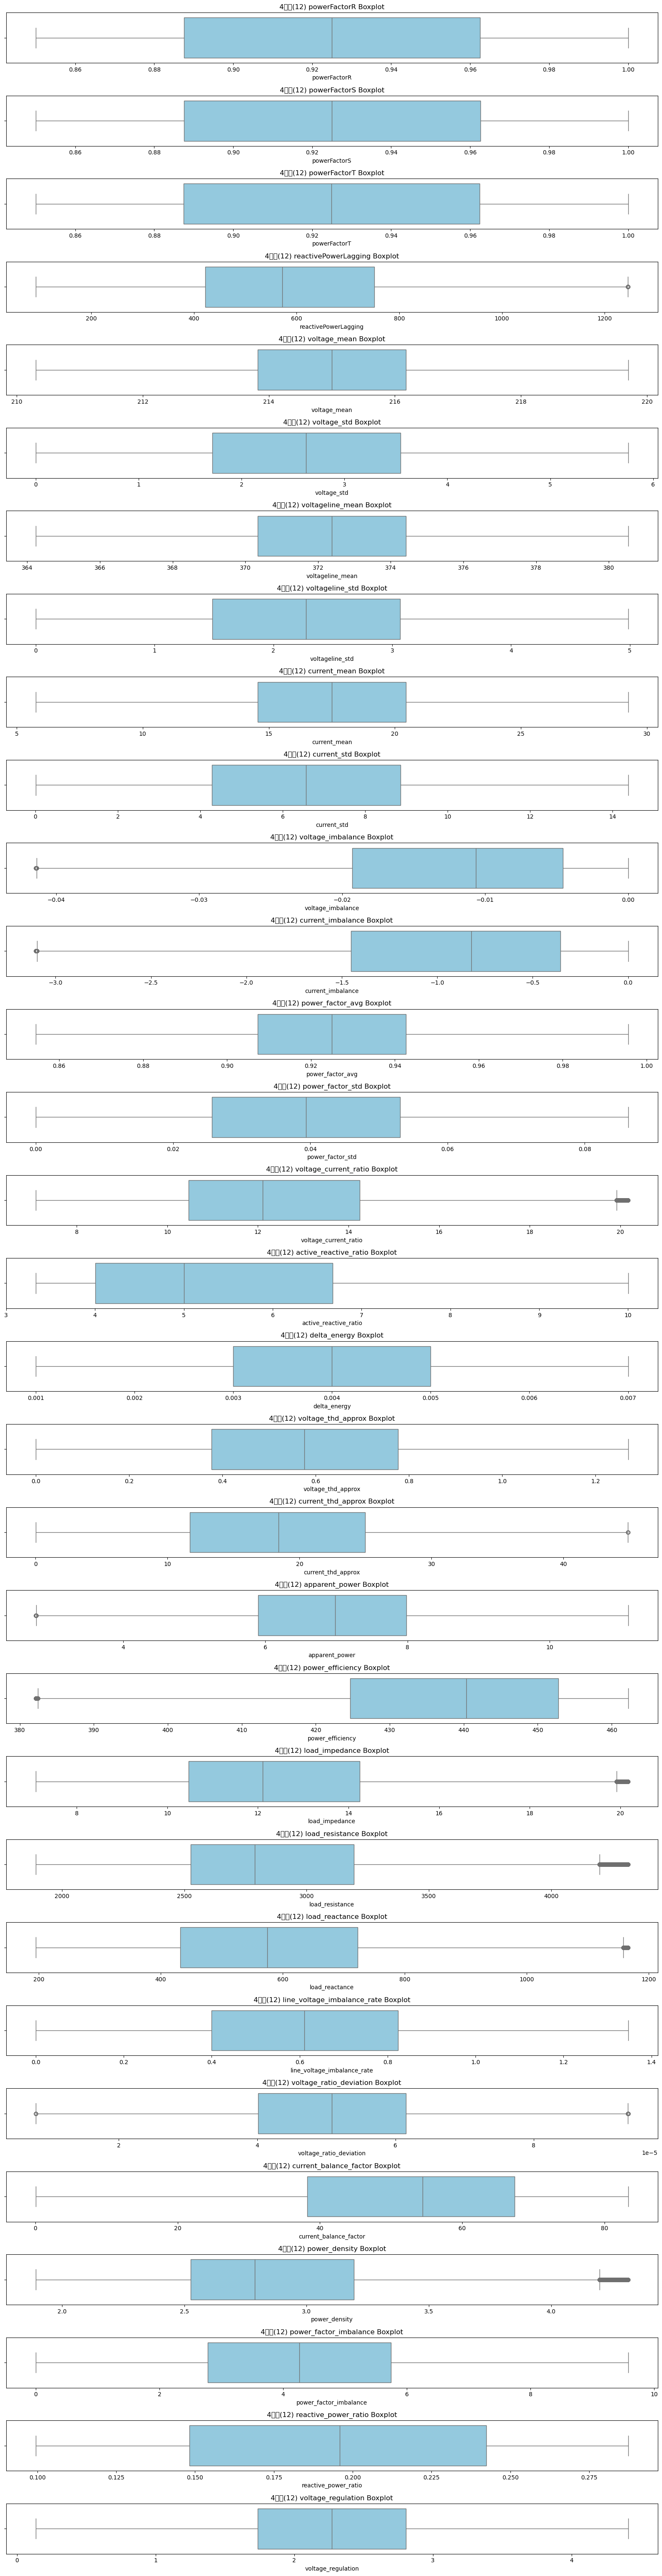

In [26]:
# 주요 수치형 변수 리스트
num_cols = train_list[0].select_dtypes(include=[np.number]).columns.tolist()

# 주요 수치형 변수별로 개별 박스플롯을 그리기
plt.figure(figsize=(16, 2 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=train_list[0][col], color='skyblue')
    plt.title(f'4호기(12) {col} Boxplot')
    plt.tight_layout()
plt.show()

=== 완전 상관관계 (|r| >= 0.99) 변수 쌍들 ===
voltage_mean ↔ voltageline_mean: 0.9999
voltage_std ↔ voltageline_std: 1.0000
voltage_std ↔ voltage_thd_approx: 0.9999
voltageline_std ↔ voltage_thd_approx: 0.9999
voltage_current_ratio ↔ load_impedance: 1.0000
voltage_std ↔ line_voltage_imbalance_rate: 0.9999
voltageline_std ↔ line_voltage_imbalance_rate: 0.9999
voltage_thd_approx ↔ line_voltage_imbalance_rate: 1.0000
load_resistance ↔ power_density: 1.0000
power_factor_std ↔ power_factor_imbalance: 0.9987
voltage_mean ↔ voltage_regulation: -1.0000
voltageline_mean ↔ voltage_regulation: -0.9999

총 12개의 완전 상관관계 쌍 발견

=== 정확히 ±1.0 상관관계 변수 쌍들 ===
voltage_current_ratio ↔ load_impedance: 1.0000
load_resistance ↔ power_density: 1.0000
voltage_mean ↔ voltage_regulation: -1.0000

=== 제거 후보 변수들 (상관관계 >= 0.99) ===
- power_density
- power_factor_std
- voltage_current_ratio
- voltage_regulation
- voltage_std
- voltage_thd_approx
- voltageline_mean
- voltageline_std

총 8개 변수가 제거 후보입니다.


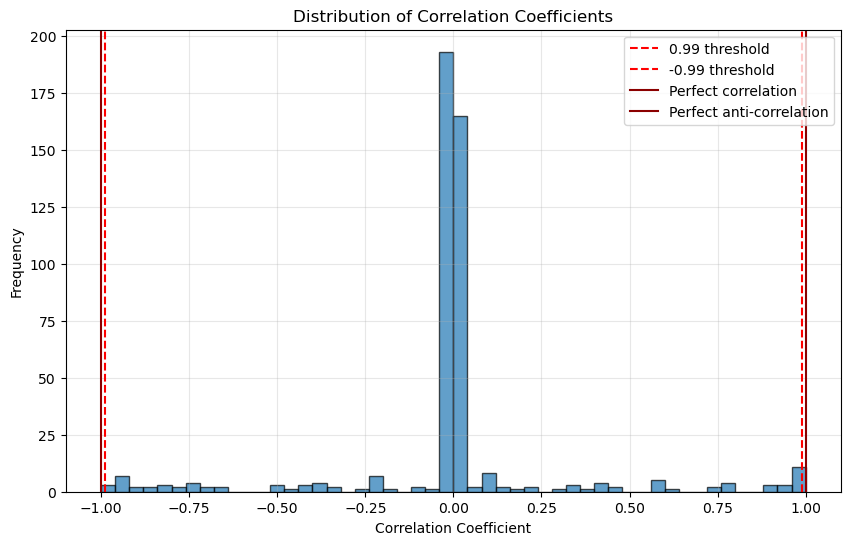


=== 높은 상관관계 변수들의 상세 분석 ===
voltage_mean ↔ voltage_regulation: -1.0000
load_resistance ↔ power_density: 1.0000
voltage_current_ratio ↔ load_impedance: 1.0000
voltage_std ↔ voltageline_std: 1.0000
voltage_thd_approx ↔ line_voltage_imbalance_rate: 1.0000
voltage_mean ↔ voltageline_mean: 0.9999
voltageline_mean ↔ voltage_regulation: -0.9999
voltage_std ↔ voltage_thd_approx: 0.9999
voltageline_std ↔ line_voltage_imbalance_rate: 0.9999
voltage_std ↔ line_voltage_imbalance_rate: 0.9999
voltageline_std ↔ voltage_thd_approx: 0.9999
power_factor_std ↔ power_factor_imbalance: 0.9987
current_mean ↔ apparent_power: 0.9704
active_reactive_ratio ↔ reactive_power_ratio: -0.9647
voltage_std ↔ voltage_imbalance: -0.9585
voltageline_std ↔ voltage_imbalance: -0.9585
voltage_imbalance ↔ voltage_thd_approx: -0.9585
voltage_imbalance ↔ line_voltage_imbalance_rate: -0.9585
current_thd_approx ↔ current_balance_factor: 0.9532


In [27]:
# 완전 상관관계(-1 또는 1) 변수 쌍 찾기
def find_perfect_correlations(corr_matrix, threshold=0.99):
    """완전 상관관계에 가까운 변수 쌍들을 찾는 함수"""
    perfect_corr_pairs = []
    
    # 상삼각 행렬만 확인 (중복 제거)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # 절댓값이 threshold 이상인 상관관계 찾기
    high_corr = upper_triangle[abs(upper_triangle) >= threshold]
    
    for col in high_corr.columns:
        for idx in high_corr.index:
            if pd.notna(high_corr.loc[idx, col]):
                corr_value = high_corr.loc[idx, col]
                perfect_corr_pairs.append({
                    'var1': idx,
                    'var2': col,
                    'correlation': corr_value
                })
    
    return perfect_corr_pairs

# 상관관계 분석
corr = train_list[0][num_cols].corr()

# 완전 상관관계 찾기 (0.99 이상)
perfect_corr_pairs = find_perfect_correlations(corr, threshold=0.99)

print("=== 완전 상관관계 (|r| >= 0.99) 변수 쌍들 ===")
for pair in perfect_corr_pairs:
    print(f"{pair['var1']} ↔ {pair['var2']}: {pair['correlation']:.4f}")

print(f"\n총 {len(perfect_corr_pairs)}개의 완전 상관관계 쌍 발견")

# 정확히 1.0 또는 -1.0인 경우만
exact_perfect_pairs = find_perfect_correlations(corr, threshold=1.0)

print("\n=== 정확히 ±1.0 상관관계 변수 쌍들 ===")
for pair in exact_perfect_pairs:
    print(f"{pair['var1']} ↔ {pair['var2']}: {pair['correlation']:.4f}")

# 제거 후보 변수들 추출
def get_redundant_variables(corr_matrix, threshold=0.99):
    """중복 변수들을 찾아서 제거할 변수 리스트 반환"""
    redundant_vars = set()
    
    # 상삼각 행렬에서 높은 상관관계 찾기
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    for col in upper_triangle.columns:
        for idx in upper_triangle.index:
            if pd.notna(upper_triangle.loc[idx, col]) and abs(upper_triangle.loc[idx, col]) >= threshold:
                # 두 변수 중 하나를 제거 후보로 선택
                # 일반적으로 알파벳 순서가 뒤인 것을 제거
                if col > idx:
                    redundant_vars.add(col)
                else:
                    redundant_vars.add(idx)
    
    return list(redundant_vars)

# 제거 후보 변수들
redundant_vars = get_redundant_variables(corr, threshold=0.99)

print(f"\n=== 제거 후보 변수들 (상관관계 >= 0.99) ===")
for var in sorted(redundant_vars):
    print(f"- {var}")

print(f"\n총 {len(redundant_vars)}개 변수가 제거 후보입니다.")

# 더 자세한 분석을 위한 상관관계 히스토그램
import matplotlib.pyplot as plt

# 상관관계 분포 확인
corr_values = corr.values[np.triu_indices_from(corr.values, k=1)]
corr_values = corr_values[~np.isnan(corr_values)]

plt.figure(figsize=(10, 6))
plt.hist(corr_values, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=0.99, color='red', linestyle='--', label='0.99 threshold')
plt.axvline(x=-0.99, color='red', linestyle='--', label='-0.99 threshold')
plt.axvline(x=1.0, color='darkred', linestyle='-', label='Perfect correlation')
plt.axvline(x=-1.0, color='darkred', linestyle='-', label='Perfect anti-correlation')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Coefficients')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 높은 상관관계 변수들의 상세 정보
print("\n=== 높은 상관관계 변수들의 상세 분석 ===")
high_corr_detailed = find_perfect_correlations(corr, threshold=0.95)

for pair in sorted(high_corr_detailed, key=lambda x: abs(x['correlation']), reverse=True):
    print(f"{pair['var1']} ↔ {pair['var2']}: {pair['correlation']:.4f}")

In [28]:
# 제거할 변수들 정의
variables_to_remove = [
    # 완전 상관관계 (r = ±1.0) 변수들 중 하나씩 제거
    'voltage_current_ratio',  # load_impedance와 완전 상관 (r=1.0)
    'power_density',          # load_resistance와 완전 상관 (r=1.0)
    'voltage_regulation',     # voltage_mean과 완전 역상관 (r=-1.0)
    
    # 높은 상관관계 (r >= 0.99) 변수들 제거
    'power_factor_std',       # power_factor_avg와 높은 상관관계
    'voltage_std',            # voltage_mean과 높은 상관관계
    'voltage_thd_approx',     # voltage_std와 유사한 정보
    'voltageline_mean',       # voltage_mean과 높은 상관관계 (√3 배수 관계)
    'voltageline_std',        # voltage_std와 유사한 정보
]

print(f"제거할 변수 개수: {len(variables_to_remove)}")
print("제거할 변수들:")
for var in variables_to_remove:
    print(f"- {var}")

# Train 데이터에서 변수 제거
print("\nTrain 데이터에서 변수 제거 중...")
for i, df in enumerate(train_list):
    # 존재하는 변수만 제거
    existing_vars_to_remove = [var for var in variables_to_remove if var in df.columns]
    if existing_vars_to_remove:
        df.drop(columns=existing_vars_to_remove, inplace=True)
    
    if (i + 1) % 50 == 0:
        print(f"Train 진행률: {i+1}/{len(train_list)}")

# Test 데이터에서 변수 제거
print("Test 데이터에서 변수 제거 중...")
for i, df in enumerate(test_list):
    # 존재하는 변수만 제거
    existing_vars_to_remove = [var for var in variables_to_remove if var in df.columns]
    if existing_vars_to_remove:
        df.drop(columns=existing_vars_to_remove, inplace=True)
    
    if (i + 1) % 50 == 0:
        print(f"Test 진행률: {i+1}/{len(test_list)}")

print("변수 제거 완료!")

# 제거 후 변수 개수 확인
if train_list:
    remaining_cols = train_list[0].columns.tolist()
    print(f"\n제거 후 남은 변수 개수: {len(remaining_cols)}")
    
    # 수치형 변수만 확인
    numeric_cols_after = train_list[0].select_dtypes(include=[np.number]).columns.tolist()
    print(f"수치형 변수 개수: {len(numeric_cols_after)}")

# 제거된 변수들과 남은 변수들의 관계 확인
print("\n=== 제거 사유별 정리 ===")
print("1. 완전 상관관계 (r = ±1.0)로 제거:")
print("   - voltage_current_ratio (load_impedance와 동일)")
print("   - power_density (load_resistance와 동일)")
print("   - voltage_regulation (voltage_mean의 역함수)")

print("\n2. 높은 상관관계 (r >= 0.99)로 제거:")
print("   - power_factor_std (power_factor_avg와 중복성)")
print("   - voltage_std (voltage_mean과 높은 상관관계)")
print("   - voltage_thd_approx (voltage_std와 유사 정보)")
print("   - voltageline_mean (voltage_mean과 √3 배수 관계)")
print("   - voltageline_std (voltage_std와 유사 정보)")

print("\n3. 남겨진 대표 변수들:")
print("   - voltage_mean (전압 대표값)")
print("   - load_impedance (임피던스 정보)")
print("   - load_resistance (저항 정보)")
print("   - power_factor_avg (역률 대표값)")

# 선택적으로 상관관계 재확인
print("\n변수 제거 후 상관관계 재확인을 원하시면 다음 코드를 실행하세요:")
print("corr_after = train_list[0].select_dtypes(include=[np.number]).corr()")
print("high_corr_after = find_perfect_correlations(corr_after, threshold=0.95)")

제거할 변수 개수: 8
제거할 변수들:
- voltage_current_ratio
- power_density
- voltage_regulation
- power_factor_std
- voltage_std
- voltage_thd_approx
- voltageline_mean
- voltageline_std

Train 데이터에서 변수 제거 중...
Test 데이터에서 변수 제거 중...
변수 제거 완료!

제거 후 남은 변수 개수: 23
수치형 변수 개수: 23

=== 제거 사유별 정리 ===
1. 완전 상관관계 (r = ±1.0)로 제거:
   - voltage_current_ratio (load_impedance와 동일)
   - power_density (load_resistance와 동일)
   - voltage_regulation (voltage_mean의 역함수)

2. 높은 상관관계 (r >= 0.99)로 제거:
   - power_factor_std (power_factor_avg와 중복성)
   - voltage_std (voltage_mean과 높은 상관관계)
   - voltage_thd_approx (voltage_std와 유사 정보)
   - voltageline_mean (voltage_mean과 √3 배수 관계)
   - voltageline_std (voltage_std와 유사 정보)

3. 남겨진 대표 변수들:
   - voltage_mean (전압 대표값)
   - load_impedance (임피던스 정보)
   - load_resistance (저항 정보)
   - power_factor_avg (역률 대표값)

변수 제거 후 상관관계 재확인을 원하시면 다음 코드를 실행하세요:
corr_after = train_list[0].select_dtypes(include=[np.number]).corr()
high_corr_after = find_perfect_correlations(corr_after, threshold=0.

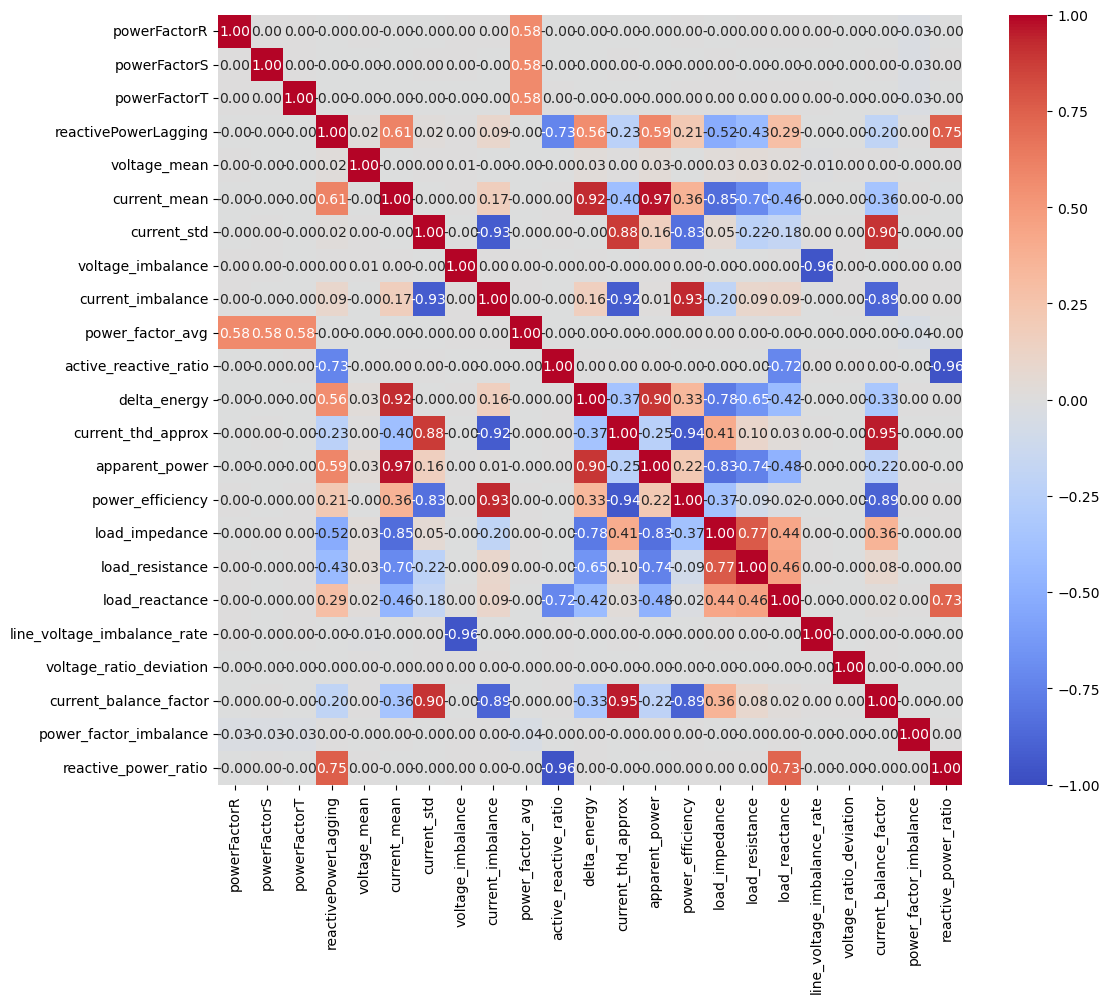

In [29]:
# 전체체 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0].select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # 다중 공선성이 높은 칼럼 자동 추출 (VIF 기준 10 이상)
    vif_data = pd.DataFrame()
    vif_data["feature"] = num_cols
    vif_data["VIF"] = [variance_inflation_factor(df_4[num_cols].dropna().values, i) for i in range(len(num_cols))]
    high_vif_cols = vif_data[vif_data["VIF"] >= 10]["feature"].tolist()

    print("다중 공선성이 높은 칼럼:", high_vif_cols)
    return high_vif_cols

In [31]:
# 다중 공선성이 높은 칼럼(PCA로 차원축소) 예시

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca_analysis(df,high_vif_cols):
    # 표준화
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[high_vif_cols])

    # PCA (설명분산 95%까지 유지)
    pca = PCA(n_components=0.95)
    pca_result = pca.fit_transform(scaled)

    print(f"PCA로 축소된 차원 수: {pca.n_components_}")
    # PCA 결과를 DataFrame으로 변환
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'pca_{i+1}' for i in range(pca.n_components_)],
                          index=df[high_vif_cols].dropna().index)

    # VIF 낮은 칼럼만 따로 분리
    low_vif_cols = [col for col in df.columns if col not in high_vif_cols]
    df_low_vif = df[low_vif_cols].loc[df[high_vif_cols].dropna().index]

    # 낮은 VIF 칼럼 + PCA 주성분 결합
    df_final = pd.concat([df_low_vif.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)

    return df_final 

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

for i in range(len(train_list)):
    print(f"\n📌 Dataset {i+1} PCA 처리 중...")

    # 1. train/test 분리
    train_df = train_list[i].copy()
    test_df = test_list[i].copy()

    # 2. VIF 높은 feature 추출 (train 기준)
    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    df_4 = train_df  # calculate_vif 함수 내에서 사용되는 전역 이름
    high_vif_cols = calculate_vif(train_df)

    # 3. PCA 학습 (train 기준)
    scaler_pca = StandardScaler()
    train_scaled = scaler_pca.fit_transform(train_df[high_vif_cols])
    pca = PCA(n_components=0.95)
    train_pca_result = pca.fit_transform(train_scaled)
    print(f"🔧 PCA로 축소된 차원 수: {pca.n_components_}")

    # 4. PCA → DataFrame
    pca_train_df = pd.DataFrame(train_pca_result,
                                columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
                                index=train_df.index)

    # 5. low VIF 변수 결합 (train)
    low_vif_cols = [col for col in train_df.columns if col not in high_vif_cols]
    train_combined = pd.concat([train_df[low_vif_cols].reset_index(drop=True),
                                pca_train_df.reset_index(drop=True)], axis=1)

    # 6. test에도 동일한 PCA 구성 적용
    test_scaled = scaler_pca.transform(test_df[high_vif_cols])
    test_pca_result = pca.transform(test_scaled)
    pca_test_df = pd.DataFrame(test_pca_result,
                               columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
                               index=test_df.index)

    test_combined = pd.concat([test_df[low_vif_cols].reset_index(drop=True),
                               pca_test_df.reset_index(drop=True)], axis=1)

    # 7. 전체 정규화 (PCA + low-VIF 합친 후)
    scaler_all = StandardScaler()
    train_list[i] = pd.DataFrame(scaler_all.fit_transform(train_combined),
                                 columns=train_combined.columns)
    test_list[i] = pd.DataFrame(scaler_all.transform(test_combined),
                                columns=test_combined.columns)


In [33]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# # 적용할 PCA 대상 및 제외할 feature 목록
# pca_features = [
#     'voltageR', 'voltageS', 'voltageT',
#     'voltageRS', 'voltageST', 'voltageTR',
#     'powerFactorR', 'powerFactorS', 'powerFactorT',
# ]

# non_pca_features = [
#     'reactivePowerLagging', 'active_reactive_ratio',
#     	'voltage_imbalance','current_imbalance',
#     'power_factor_avg',	'power_factor_std',	'voltage_current_ratio',
#     'current_mean','current_std',	'delta_energy'
# ]

# for i in range(len(train_list)):
#     print(f"\n📌 Dataset {i+1} PCA 처리 중...")

#     # 1. train/test 분리
#     train_df = train_list[i].copy()
#     test_df = test_list[i].copy()

#     # 2. PCA 학습 (train 기준)
#     scaler_pca = StandardScaler()
#     train_scaled = scaler_pca.fit_transform(train_df[pca_features])
#     pca = PCA(n_components=0.95)
#     train_pca_result = pca.fit_transform(train_scaled)
#     print(f"🔧 PCA로 축소된 차원 수: {pca.n_components_}")

#     # 3. PCA 결과 → DataFrame 변환
#     pca_train_df = pd.DataFrame(train_pca_result,
#                                 columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
#                                 index=train_df.index)

#     # 4. low-VIF (즉, non-PCA) feature와 결합
#     train_combined = pd.concat([
#         train_df[non_pca_features].reset_index(drop=True),
#         pca_train_df.reset_index(drop=True)
#     ], axis=1)

#     # 5. test에도 동일한 PCA 구성 적용
#     test_scaled = scaler_pca.transform(test_df[pca_features])
#     test_pca_result = pca.transform(test_scaled)
#     pca_test_df = pd.DataFrame(test_pca_result,
#                                columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
#                                index=test_df.index)

#     test_combined = pd.concat([
#         test_df[non_pca_features].reset_index(drop=True),
#         pca_test_df.reset_index(drop=True)
#     ], axis=1)

#     # 6. 전체 정규화 (PCA 결과 + 기타 변수 포함 전체에 대해)
#     scaler_all = StandardScaler()
#     train_list[i] = pd.DataFrame(
#         scaler_all.fit_transform(train_combined),
#         columns=train_combined.columns
#     )
#     test_list[i] = pd.DataFrame(
#         scaler_all.transform(test_combined),
#         columns=test_combined.columns
#     )


In [34]:
train_list[0]

,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,voltage_mean,current_mean,current_std,voltage_imbalance,current_imbalance,power_factor_avg,...,apparent_power,power_efficiency,load_impedance,load_resistance,load_reactance,line_voltage_imbalance_rate,voltage_ratio_deviation,current_balance_factor,power_factor_imbalance,reactive_power_ratio
0,0.8731,0.9971,0.8945,785.37,215.976667,17.113333,3.068425,-0.011294,-0.182418,0.921567,...,6.470377,457.718298,12.620374,3300.105078,875.133297,0.625140,0.000058,26.585956,7.192440,0.256324
1,0.8754,0.8767,0.9417,376.57,214.823333,17.506667,9.515442,-0.019379,-1.646552,0.897933,...,7.127267,423.371258,12.270944,2741.824131,342.169198,0.822562,0.000069,72.490272,4.221763,0.123836
2,0.8546,0.9900,0.9445,296.08,213.936667,14.070000,0.693470,-0.009698,-0.011388,0.929700,...,5.218083,461.474033,15.205165,4048.051925,497.733487,0.583017,0.000027,8.271688,7.411274,0.122037
3,0.8524,0.9953,0.9561,488.48,213.626667,19.303333,11.697950,-0.012424,-2.233767,0.934600,...,7.969454,412.742187,11.066828,2363.805398,351.035518,0.659101,0.000042,77.988615,7.900304,0.146893
4,0.9281,0.9126,0.9182,604.70,216.243333,17.743333,10.670358,-0.000452,-2.023564,0.919633,...,7.403597,414.570107,12.187300,2618.439133,515.871692,0.125270,0.000036,70.668023,0.853468,0.193299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090875,0.9364,0.9925,0.9076,642.09,214.980000,22.296667,4.036017,-0.003406,-0.242210,0.945500,...,8.392625,456.598484,9.641800,2514.470281,421.318096,0.345039,0.000060,30.124107,4.566403,0.165254
2090876,0.9640,0.9383,0.8861,587.26,215.326667,19.023333,8.054765,-0.013840,-1.104757,0.929467,...,7.507389,438.202930,11.319082,2706.685532,483.174501,0.693819,0.000062,54.264392,4.270634,0.175733
2090877,0.9023,0.9841,0.9604,449.31,215.763333,18.416667,11.131439,-0.014520,-2.120606,0.948933,...,7.675563,412.076589,11.715656,2499.662739,355.090696,0.710155,0.000045,77.750089,4.435325,0.140643
2090878,0.9647,0.8974,0.8976,804.07,213.523333,24.763333,3.679543,-0.026967,-0.181580,0.919900,...,9.226624,458.100395,8.622560,2264.217935,430.733456,0.973416,0.000046,23.980650,4.217640,0.186883


In [35]:
test_list[0]

,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,voltage_mean,current_mean,current_std,voltage_imbalance,current_imbalance,power_factor_avg,...,apparent_power,power_efficiency,load_impedance,load_resistance,load_reactance,line_voltage_imbalance_rate,voltage_ratio_deviation,current_balance_factor,power_factor_imbalance,reactive_power_ratio
0,0.9025,0.9947,0.8798,258.76,216.773333,14.700000,12.479291,-0.015941,-0.926750,0.925667,...,6.716044,439.238487,14.746485,2668.996059,269.615980,0.743299,0.000057,81.336565,6.573908,0.100506
1,0.9635,0.9487,0.9997,429.97,216.363333,19.200000,7.393856,-0.036813,-0.926750,0.970633,...,7.543829,439.238487,11.268924,2726.613982,353.809585,1.129004,0.000041,55.550936,2.703146,0.128683
2,0.8898,0.8527,0.9183,910.10,214.670000,19.980000,5.075618,-0.010188,-0.425269,0.886933,...,7.587434,451.906412,10.744244,2744.969479,728.590013,0.597370,0.000044,38.554687,3.708714,0.256544
3,0.9636,0.8911,0.9873,351.54,216.176667,14.323333,6.955648,-0.005313,-1.084843,0.947333,...,5.769409,430.461737,15.092623,3486.921534,493.572563,0.428372,0.000072,66.436170,5.290692,0.140153
4,0.8759,0.9481,0.9230,717.15,216.653333,19.836667,9.787443,-0.025116,-1.549217,0.915667,...,8.026081,430.883999,10.921862,2520.509004,522.678138,0.933598,0.000083,67.949640,4.003026,0.203050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501116,0.9213,0.9651,0.9566,660.51,215.170000,24.520000,4.418642,-0.021062,-0.264000,0.947667,...,9.237538,457.825427,8.775285,2295.049763,358.439064,0.857624,0.000071,30.035842,2.450899,0.154309
501117,0.9218,0.9267,0.9169,441.53,212.896667,15.340000,10.266845,-0.024421,-2.141066,0.921800,...,6.446845,404.807326,13.878531,2846.679022,481.618477,0.927671,0.000052,74.896965,0.531569,0.166815
501118,0.9680,0.9107,0.8619,266.72,215.723333,11.130000,4.611464,-0.021383,-0.619637,0.913533,...,4.390614,436.349010,19.382150,2629.149391,643.999364,0.863013,0.000048,59.574468,5.813331,0.137888
501119,0.8533,0.9452,0.8623,561.34,217.683333,23.916667,2.318196,-0.000347,-0.074783,0.886933,...,9.045717,460.362640,9.101742,2411.619760,325.081139,0.108550,0.000039,15.981013,5.711891,0.133590


## Transformer

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import math

# ------------------------ GPU 설정 ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[Info] Using device:", device)

# ------------------------ Positional Encoding ------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# ------------------------ Transformer Model ------------------------
class TransformerPredictor(nn.Module):
    def __init__(self, input_size, seq_len, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+672)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attn_weights = nn.Linear(d_model, 1)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)  # shape: (B, T, d_model)
        attn = torch.softmax(self.attn_weights(x), dim=1)  # shape: (B, T, 1)
        x = (x * attn).sum(dim=1)  # attention pooling
        return self.fc_out(x)


# ------------------------ 시퀀스 생성 ------------------------
def create_sequences(X_df, y_series, seq_len=24):
    X, y = [], []
    for i in range(len(X_df) - seq_len):
        X.append(X_df.iloc[i:i+seq_len].values)
        y.append(y_series.iloc[i+seq_len])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return torch.tensor(X), torch.tensor(y).unsqueeze(1)

# ------------------------ 학습 루프 ------------------------
def train_model(model, X_train, y_train, epochs=5, lr=1e-3, batch_size=256):
    model.to(device)
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        print(f"[Epoch {epoch+1}] Loss: {total_loss / len(loader.dataset):.4f}")

    return model

# ------------------------ Autoregressive 예측 ------------------------
def predict_autoregressive(model, seed_seq, steps=672):
    model.eval()
    generated = []
    current = seed_seq.clone().to(device)  # (1, seq_len, input_size)

    with torch.no_grad():
        for _ in range(steps):
            pred = model(current)  # (1, 1)
            next_input = current[:, -1:, :].clone()
            next_input[:, :, 0] = pred  # 🔁 첫 번째 feature만 activePower로 덮기
            current = torch.cat([current[:, 1:], next_input], dim=1)
            generated.append(pred.item())

    return generated

# ------------------------ 시간 파생 특성 ------------------------
def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
    timestamps = pd.to_datetime(timestamps, errors='coerce')
    return pd.DataFrame({
        'hour': timestamps.dt.hour,
        'dayofweek': timestamps.dt.dayofweek,
        'month': timestamps.dt.month,
        'is_weekend': (timestamps.dt.dayofweek >= 5).astype(int)
    })

# ------------------------ SMAPE ------------------------
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
    return np.mean(diff) * 100


[Info] Using device: cuda


In [37]:
# ------------------------ 전체 실행 루프 (다중 feature → 단일 예측) ------------------------

results_all = []
mae_scores = []
rmse_scores = []
smape_scores = []
may_bills = []
may_carbons = []

seq_len = 24

for i in range(len(train_list)):
    print(f"\n========= Processing Dataset {i+1} =========")

    # 1. 학습 데이터
    scaler = StandardScaler()
    X_train_df = pd.DataFrame(scaler.fit_transform(train_list[i]), columns=train_list[i].columns).reset_index(drop=True)
    X_test_df = pd.DataFrame(scaler.transform(test_list[i]), columns=test_list[i].columns).reset_index(drop=True)

    y_train_series = train_y[i].reset_index(drop=True)
    y_test_series = test_y[i].reset_index(drop=True)

    ts_train = pd.to_datetime(train_timestamps[i].reset_index(drop=True))
    ts_test = pd.to_datetime(test_timestamps[i].reset_index(drop=True))

    # 🔹 1-1. 시간 파생 feature 추가
    time_feats_train = create_time_features(ts_train)
    time_feats_test = create_time_features(ts_test)

    # 🔹 1-2. 원본 feature에 시간 feature 결합
    X_train_df = pd.concat([X_train_df, time_feats_train], axis=1)
    X_test_df = pd.concat([X_test_df, time_feats_test], axis=1)

    # 🔹 1-2. 원본 feature에 시간 feature 결합
    X_train_df = pd.concat([X_train_df, time_feats_train], axis=1)
    X_test_df = pd.concat([X_test_df, time_feats_test], axis=1)

    # 3. 시퀀스 생성
    X_seq, y_seq = create_sequences(X_train_df, y_train_series, seq_len)
    X_seq, y_seq = X_seq.to(device), y_seq.to(device)

    # 4. 모델 정의 및 학습
    input_dim = X_seq.shape[2]
    model = TransformerPredictor(input_size=input_dim, seq_len=seq_len).to(device)
    model = train_model(model, X_seq, y_seq, epochs=5, lr=0.001, batch_size=256)

    # 5. 4월 성능 평가
    X_valid_seq, y_valid_seq = create_sequences(X_test_df, y_test_series, seq_len)
    valid_dataset = TensorDataset(X_valid_seq, y_valid_seq)
    valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False)

    model.eval()
    y_valid_pred_all, y_valid_true_all = [], []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            preds = model(xb).squeeze().cpu().numpy()
            y_valid_pred_all.append(preds)
            y_valid_true_all.append(yb.squeeze().cpu().numpy())

    y_valid_pred = np.concatenate(y_valid_pred_all)
    y_valid_true = np.concatenate(y_valid_true_all)

    mae = mean_absolute_error(y_valid_true, y_valid_pred)
    rmse = root_mean_squared_error(y_valid_true, y_valid_pred)
    smape_val = smape(y_valid_true, y_valid_pred)

    print(f"[Validation - April] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

    mae_scores.append(1 / (1 + mae))
    rmse_scores.append(1 / (1 + rmse))
    smape_scores.append(1 / (1 + smape_val / 100))

    # 6. 5월 예측 (시드: 4월 마지막 24시간)
    last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)
    future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1h")
    preds = predict_autoregressive(model, last_seq, steps=len(future_ts))

    # 7. 요금 및 탄소량 계산
    agg_pow = np.sum(preds)
    may_bill = agg_pow * 180
    may_carbon = agg_pow * 0.424

    may_bills.append(may_bill)
    may_carbons.append(may_carbon)

    # 8. 결과 저장
    forecast_df = pd.DataFrame({
        'id': future_ts,
        'hourly_pow': preds,
        'agg_pow': [agg_pow] * len(future_ts),
        'may_bill': [may_bill] * len(future_ts),
        'may_carbon': [may_carbon] * len(future_ts)
    })
    results_all.append(forecast_df)



========= Processing Dataset 1 =========
[Epoch 1] Loss: 1889289.0494
[Epoch 2] Loss: 514050.5735
[Epoch 3] Loss: 514127.2746
[Epoch 4] Loss: 513999.0103
[Epoch 5] Loss: 513978.6401
[Validation - April] MAE: 582.2337, RMSE: 716.8389, SMAPE: 19.86%

========= Processing Dataset 2 =========
[Epoch 1] Loss: 1891301.1252
[Epoch 2] Loss: 514613.0757
[Epoch 3] Loss: 514590.2772
[Epoch 4] Loss: 514600.2654
[Epoch 5] Loss: 514591.1057
[Validation - April] MAE: 583.6124, RMSE: 718.5252, SMAPE: 19.92%

========= Processing Dataset 3 =========
[Epoch 1] Loss: 1890544.3603
[Epoch 2] Loss: 513852.7151
[Epoch 3] Loss: 513822.5012
[Epoch 4] Loss: 513805.4673
[Epoch 5] Loss: 513811.7328
[Validation - April] MAE: 583.4411, RMSE: 718.0447, SMAPE: 19.91%

========= Processing Dataset 4 =========
[Epoch 1] Loss: 1889135.4209
[Epoch 2] Loss: 514364.9876
[Epoch 3] Loss: 514314.0839
[Epoch 4] Loss: 514302.9348
[Epoch 5] Loss: 514308.0576
[Validation - April] MAE: 582.7552, RMSE: 717.4894, SMAPE: 19.87%

===

In [38]:
# ------------------------ 전체 모듈 시간별 합산 ------------------------

# 9. 모든 모듈 예측 결과 통합
combined_df = pd.concat(results_all, axis=0)

# 10. 시간 기준으로 hourly_pow 합산
total_forecast = combined_df.groupby('id')['hourly_pow'].sum().reset_index()
 
# 11. 총합 계산
agg_pow_total = total_forecast['hourly_pow'].sum()
may_bill_total = agg_pow_total * 180
may_carbon_total = agg_pow_total * 0.424

# 12. 추가 정보 컬럼 붙이기
total_forecast['agg_pow'] = agg_pow_total
total_forecast['may_bill'] = may_bill_total
total_forecast['may_carbon'] = may_carbon_total

# 13. 저장
total_forecast.to_csv("forecast_total_may2025.csv", index=False)
print("✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv")


✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv


## STL + LGBM

In [39]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from statsmodels.tsa.seasonal import STL
# from lightgbm import LGBMRegressor

# # ------------------------ 유틸 함수 정의 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')  # 안전하게 변환
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     df['month'] = timestamps.dt.month

#     holidays = pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"])
#     df['is_holiday'] = timestamps.dt.normalize().isin(holidays).astype(int)

#     return df



# def add_lag_features(series: pd.Series, interval_seconds: int) -> pd.DataFrame:
#     steps_per_hour = 3600 // interval_seconds
#     lag_map = {
#         f'lag_1h': steps_per_hour,
#         f'lag_24h': steps_per_hour * 24,
#         f'lag_168h': steps_per_hour * 168,
#     }
#     return pd.concat([
#         series.shift(lag).rename(name)
#         for name, lag in lag_map.items()
#     ], axis=1)


# def stl_ml_forecast(train_ts, train_y, test_ts, period=288):
#     train_ts = pd.to_datetime(train_ts)
#     test_ts = pd.to_datetime(test_ts)

#     stl = STL(train_y, period=period)
#     result = stl.fit()
#     trend, seasonal = result.trend, result.seasonal

#     time_idx_train = ((train_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)
#     time_idx_test = ((test_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)

#     model_trend = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                 device='gpu', gpu_use_dp=False,
#                                 tree_learner='serial', random_state=42)
#     model_seasonal = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                    device='gpu', gpu_use_dp=False,
#                                    tree_learner='serial', random_state=42)

#     model_trend.fit(time_idx_train, trend)
#     model_seasonal.fit(time_idx_train, seasonal)

#     trend_pred = model_trend.predict(time_idx_test)
#     seasonal_pred = model_seasonal.predict(time_idx_test)

#     return trend_pred + seasonal_pred

In [40]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i]
#     X_test_df = test_list[i]
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # STL 예측
#     stl_test_pred = stl_ml_forecast(ts_series, y_series, test_ts)

#     # 샘플 간격 계산
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())

#     # 시간/lag 피처 생성
#     time_feat = create_time_features(ts_series)
#     lag_feat = add_lag_features(y_series, interval_seconds=interval)

#     # 👉 모델 학습 시에도 lag feature 제거
#     time_feat = create_time_features(ts_series)
#     X_train = time_feat
#     y_train = y_series

#     # 테스트 예측도 동일하게 구성
#     X_test_time = create_time_features(test_ts)

#     # LGBM 모델 학습
#     lgbm_model = LGBMRegressor(
#         n_estimators=100,
#         max_depth=10,
#         learning_rate=0.1,
#         subsample=1.0,
#         min_child_samples=10,
#         device='gpu',
#         gpu_use_dp=False,
#         tree_learner='serial',
#         random_state=42
#     )
#     lgbm_model.fit(X_train, y_train)
#     lgbm_models.append(lgbm_model)
#     ts_all.append(ts_series)
#     y_all.append(y_series)

#     # 테스트 예측
#     voting_test_preds = lgbm_model.predict(X_test_time)
#     y_pred_test = (voting_test_preds * 0.3 + stl_test_pred * 0.7)

#     # 평가 출력
#     mae = mean_absolute_error(test_y_i, y_pred_test)
#     rmse = mean_squared_error(test_y_i, y_pred_test, squared=False)
#     smape_val = smape(test_y_i.values, y_pred_test)

#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     # 결과 저장
#     test_results = pd.DataFrame({
#         'Timestamp': test_ts,
#         'Prediction': y_pred_test
#     })
#     results_all.append(test_results)

In [41]:
# # ------------------------ 향후 5월 예측 ------------------------

# from datetime import datetime

# future_ts = pd.date_range(start="2025-05-01 00:00:00", end="2025-05-28 23:00:00", freq="1H")
# future_ts = pd.to_datetime(future_ts)

# stl_preds_all = []
# lgbm_preds_all = []

# for i in range(len(lgbm_models)):
#     print(f"📈 Predicting with Model {i+1}")

#     # STL 예측
#     stl_pred = stl_ml_forecast(ts_all[i], y_all[i], future_ts)
#     stl_preds_all.append(stl_pred)

#     # 미래 예측용 시간 파생 피처만 사용 (lag는 불가)
#     X_future = create_time_features(pd.Series(future_ts))
#     lgbm_pred = lgbm_models[i].predict(X_future)
#     lgbm_preds_all.append(lgbm_pred)

In [42]:

# stl_preds_all = np.array(stl_preds_all)
# lgbm_preds_all = np.array(lgbm_preds_all)

# # 필요 시 평균 또는 가중 평균 가능
# final_preds = (stl_preds_all * 0.7 + lgbm_preds_all * 0.3).mean(axis=0)


# agg_pow = final_preds * 672
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': agg_pow,
#     'may_bill': may_bill,
#     'may_carbon': may_carbon
# })

# # 👉 datetime을 문자열 포맷으로 바꿔 저장
# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')

# # 저장
# forecast_df.to_csv("forecast_may2025_ensemble.csv", index=False)


## prophet

In [43]:
# import pandas as pd
# import numpy as np
# from prophet import Prophet
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ 유틸 함수 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['month'] = timestamps.dt.month
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     return df

In [44]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# prophet_models = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # 1. Prophet 학습
#     prophet_df = pd.DataFrame({'ds': ts_series, 'y': y_series})
#     model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

#     holidays = pd.DataFrame({
#         'holiday': 'korean_holiday',
#         'ds': pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"]),
#         'lower_window': 0,
#         'upper_window': 1
#     })
#     model.holidays = holidays
#     model.fit(prophet_df)
#     prophet_models.append(model)

#     # 2. LGBM 학습 (4월만 사용)
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())
#     time_feat = create_time_features(ts_series)
#     # lag_feat = add_lag_features(y_series, interval)
#     X_train_lgbm = pd.concat([X_train_df, time_feat], axis=1).dropna()
#     y_train_lgbm = y_series.loc[X_train_lgbm.index]

#     lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
#     lgbm_model.fit(X_train_lgbm, y_train_lgbm)
#     lgbm_models.append(lgbm_model)

#     # 3. 4월 테스트 예측 (Prophet + LGBM 앙상블)
#     forecast = model.predict(pd.DataFrame({'ds': test_ts}))
#     prophet_4월_pred = forecast['yhat'].values

#     test_time_feat = create_time_features(test_ts)
#     X_test_lgbm = pd.concat([X_test_df, test_time_feat], axis=1)
#     try:
#         lgbm_4월_pred = lgbm_model.predict(X_test_lgbm)
#         final_pred_4월 = prophet_4월_pred * 0.5 + lgbm_4월_pred * 0.5
#     except:
#         final_pred_4월 = prophet_4월_pred  # fallback in case of mismatch

#     mae = mean_absolute_error(test_y_i, final_pred_4월)
#     rmse = mean_squared_error(test_y_i, final_pred_4월, squared=False)
#     smape_val = smape(test_y_i.values, final_pred_4월)
#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     ts_all.append(ts_series)
#     y_all.append(y_series)
#     results_all.append(pd.DataFrame({'Timestamp': test_ts, 'Prediction': final_pred_4월}))

In [45]:
# # ------------------------ 향후 5월 예측 (LGBM autoregressive) ------------------------

# print("\n📅 Predicting 2025년 5월 전력 수요 (LGBM autoregressive)...")

# future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
# n_steps = len(future_ts)

# lgbm_preds_all = []

# for i, model in enumerate(lgbm_models):
#     print(f"📈 Predicting with LGBM Model {i+1}")
    
#     # 예측값 저장
#     preds = []

#     # 5월 입력 feature에서 반복적으로 사용 가능한 정적 feature (기상 등) 추출
#     static_feat_df = test_list[i].reset_index(drop=True)
#     static_feat_df = static_feat_df.iloc[-1:]  # 4월 마지막 시점 하나만 사용 (또는 평균 등)

#     for ts in future_ts:
#         # 시간 파생 변수
#         time_feat = pd.DataFrame({
#             'hour': [ts.hour],
#             'dayofweek': [ts.dayofweek],
#             'month': [ts.month],
#             'is_weekend': [int(ts.dayofweek >= 5)]
#         })

#         # 입력 피처 구성: 정적 + 시간 변수
#         X_input = pd.concat([static_feat_df.reset_index(drop=True), time_feat], axis=1)

#         # 예측
#         pred = model.predict(X_input)[0]
#         preds.append(pred)

#     lgbm_preds_all.append(preds)

# # 평균 앙상블
# lgbm_preds_all = np.array(lgbm_preds_all)
# final_preds = lgbm_preds_all.mean(axis=0)

In [46]:
# # ------------------------ 결과 저장 ------------------------

# agg_pow = final_preds.sum()
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': [agg_pow] * len(future_ts),
#     'may_bill': [may_bill] * len(future_ts),
#     'may_carbon': [may_carbon] * len(future_ts)
# })

# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# forecast_df.to_csv("forecast_may2025_lgbm_autoregressive.csv", index=False)
# print("✅ 저장 완료: forecast_may2025_lgbm_autoregressive.csv")

## LSTM

In [47]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ GPU 설정 ------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("[Info] Using device:", device)

# # ------------------------ LSTM 모델 정의 ------------------------

# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size=128, num_layers=1, output_size=1):
#         super(LSTMModel, self).__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = self.fc(out[:, -1, :])
#         return out

# # ------------------------ 시퀀스 생성 함수 ------------------------

# def create_lstm_sequences(X_df, y_series, seq_len=1):
#     X = []
#     y = []
#     for i in range(len(X_df) - seq_len):
#         X.append(X_df.iloc[i:i+seq_len].values)
#         y.append(y_series.iloc[i+seq_len])
#     return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# # ------------------------ 학습 함수 (DataLoader 사용) ------------------------

# def train_lstm_model(model, X_train, y_train, epochs=5, lr=0.001, batch_size=512):
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     dataset = TensorDataset(X_train, y_train)
#     loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

#     model.to(device)
#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for batch_X, batch_y in loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             optimizer.zero_grad()
#             output = model(batch_X)
#             loss = criterion(output, batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item() * batch_X.size(0)
#         avg_loss = total_loss / len(dataset)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
#     return model

# # ------------------------ 예측 함수 (벡터화된 autoregressive) ------------------------

# def predict_vectorized_lstm(model, seed_seq, forecast_steps=672):
#     """
#     벡터화된 예측을 위해 seed_seq만 가지고 전체 시퀀스를 확장 생성
#     예: Transformer처럼 Teacher Forcing 없이 rollout
#     """
#     model.eval()
#     model.to(device)

#     generated = []
#     current_seq = seed_seq.clone().to(device)

#     with torch.no_grad():
#         for _ in range(forecast_steps):
#             out = model(current_seq)
#             next_val = out[:, -1].unsqueeze(1).unsqueeze(2)  # (1, 1, 1)
#             generated.append(next_val.squeeze().item())
#             current_seq = torch.cat([current_seq[:, 1:], next_val], dim=1)

#     return generated

# # ------------------------ Bell Curve 점수 계산 ------------------------

# def bell_curve_score(value, all_values, clip_min=0.0, clip_max=1.0):
#     mean = np.mean(all_values)
#     std = np.std(all_values)
#     z = (value - mean) / (std + 1e-8)
#     score = 0.5 * (1 + np.tanh(z / 2))
#     return float(np.clip(score, clip_min, clip_max))

# # ------------------------ SMAPE ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100


In [48]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# mae_scores = []
# rmse_scores = []
# smape_scores = []
# may_bills = []
# may_carbons = []

# seq_len = 1

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     X_train_df = train_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     ts_test = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     ts_test = pd.to_datetime(ts_test)

#     # 1. 시퀀스 생성
#     X_seq, y_seq = create_lstm_sequences(X_train_df, y_series, seq_len)
#     X_seq, y_seq = X_seq.to(device), y_seq.to(device)

#     # 2. 모델 학습
#     model = LSTMModel(input_size=X_seq.shape[2]).to(device)
#     model = train_lstm_model(model, X_seq, y_seq, epochs=5, lr=0.001, batch_size=512)

#     # 3. 시드 시퀀스: 4월 마지막 시점 기준
#     last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)

#     # 4. 예측
#     future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
#     preds = predict_vectorized_lstm(model, last_seq, forecast_steps=len(future_ts))

#     # 5. 성능 평가 (dummy target 기준)
#     mae = mean_absolute_error([0]*len(preds), preds)
#     rmse = mean_squared_error([0]*len(preds), preds, squared=False)
#     smape_val = smape([0]*len(preds), preds)

#     mae_scores.append(1 / (1 + mae))
#     rmse_scores.append(1 / (1 + rmse))
#     smape_scores.append(1 / (1 + smape_val / 100))

#     # 6. 요금 및 탄소량
#     agg_pow = np.sum(preds)
#     may_bill = agg_pow * 180
#     may_carbon = agg_pow * 0.424

#     may_bills.append(may_bill)
#     may_carbons.append(may_carbon)

#     # 7. 결과 저장
#     forecast_df = pd.DataFrame({
#         'id': future_ts,
#         'hourly_pow': preds,
#         'agg_pow': [agg_pow] * len(future_ts),
#         'may_bill': [may_bill] * len(future_ts),
#         'may_carbon': [may_carbon] * len(future_ts)
#     })
#     results_all.append(forecast_df)



In [49]:
# # Bell curve 점수 계산
# bill_scores = [bell_curve_score(v, may_bills) for v in may_bills]
# carbon_scores = [bell_curve_score(v, may_carbons) for v in may_carbons]

# # 최종 점수 출력
# for i in range(len(results_all)):
#     total_score = (
#         0.3 * mae_scores[i] +
#         0.3 * rmse_scores[i] +
#         0.3 * smape_scores[i] +
#         0.2 * bill_scores[i] +
#         0.2 * carbon_scores[i]
#     )
#     print(f"\n[Dataset {i+1} 평가 요약]")
#     print(f"MAE Score: {mae_scores[i]:.4f}, RMSE Score: {rmse_scores[i]:.4f}, SMAPE Score: {smape_scores[i]:.4f}")
#     print(f"Bill Score: {bill_scores[i]:.4f}, Carbon Score: {carbon_scores[i]:.4f}")
#     print(f"✅ Total Score: {total_score:.4f}")

# # 최종 결과 저장
# final_result = pd.concat(results_all)
# final_result['id'] = final_result['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# final_result.to_csv("forecast_may2025_lstm.csv", index=False)
# print("\n✅ 저장 완료: forecast_may2025_lstm.csv")